In [1]:
import pandas as pd
import os as os
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib.style as style

## 01. Calculate eukaryotic phyla composition for ASV samples

In [3]:
# 18S genera
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/18S comparison")
tax_freq_18S = pd.read_csv("18S_frequencies_all_tax_ranks_withBacUnass.csv")
tax_freq_18S_euk = tax_freq_18S[tax_freq_18S['Domain'] == 'Eukaryota']
#genera_18S = list(tax_freq_18S['Genus'].unique())
#phyla_genera_18S = tax_freq_18S.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})

In [4]:
tax_freq_18S.head()

,Domain,Phylum,Class,Order,Family,Genus,Species,18S sample,18S reads
0,Eukaryota,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Penicillium,unassigned,CN18FESPkoa_SC24,0.000020
1,Eukaryota,Ascomycota,unassigned,unassigned,unassigned,unassigned,unassigned,CN18FESPkoa_SC24,0.000020
2,Eukaryota,Basidiomycota,Malasseziomycetes,Malasseziales,Malasseziaceae,Malassezia,Malassezia globosa,CN18FESPkoa_SC24,0.001325
3,Eukaryota,Basidiomycota,Tremellomycetes,Tremellales,unassigned,unassigned,unassigned,CN18FESPkoa_SC24,0.000010
4,Eukaryota,Basidiomycota,Tremellomycetes,unassigned,unassigned,unassigned,unassigned,CN18FESPkoa_SC24,0.000130


In [5]:
len(tax_freq_18S['18S sample'].unique())

218

In [6]:
domain_18S = tax_freq_18S[['18S reads', 'Domain']].groupby('Domain').sum().reset_index()
domain_18S['fraction'] = domain_18S['18S reads'] / 218
domain_18S = domain_18S.drop('18S reads', axis=1)
domain_18S.head()

,Domain,fraction
0,Eukaryota,0.885841
1,unassigned,0.114159


### Combine "unknown," "unclassified", and "unassigned" annotations into "Unclassified"

In [7]:
tax_freq_18S_euk.loc[tax_freq_18S_euk['Phylum'] == 'unclassified', 'Phylum'] = "Unclassified"
tax_freq_18S_euk.loc[tax_freq_18S_euk['Phylum'] == 'unknown', 'Phylum'] = "Unclassified"
tax_freq_18S_euk.loc[tax_freq_18S_euk['Phylum'] == 'unassigned', 'Phylum'] = "Unclassified"

In [8]:
tax_freq_18S_avg = tax_freq_18S_euk.groupby(['Phylum'], as_index=False)['18S reads'].agg('sum')
tax_freq_18S_avg['fraction'] = tax_freq_18S_avg['18S reads'] / 218
tax_freq_18S_avg['Data set'] = '18S'
tax_freq_18S_avg_sort = tax_freq_18S_avg.sort_values(by='fraction', ascending=False).drop(columns='18S reads')
tax_freq_18S_avg_sort.head()

,Phylum,fraction,Data set
29,Dinophyceae,0.246863,18S
4,Arthropoda,0.199925,18S
6,Bacillariophyta,0.150031,18S
64,Unclassified,0.132250,18S
54,Polycystinea,0.019168,18S


In [9]:
tax_freq_18S_avg_sort['fraction'].sum()

np.float64(0.8858410338179125)

In [10]:
tax_freq_18S_avg_sort['Percent composition'] = tax_freq_18S_avg_sort['fraction'] / 0.885841
euk_phyla_18S = tax_freq_18S_avg_sort.drop('fraction', axis=1).rename(columns = {'phylum' : 'Phylum'})
euk_phyla_18S = euk_phyla_18S.sort_values(by='Percent composition', ascending=False)
euk_phyla_18S['Data set'] = '18S reads'
euk_phyla_18S.head()

,Phylum,Data set,Percent composition
29,Dinophyceae,18S reads,0.278676
4,Arthropoda,18S reads,0.225689
6,Bacillariophyta,18S reads,0.169366
64,Unclassified,18S reads,0.149293
54,Polycystinea,18S reads,0.021638


In [11]:
pivot_18S = pd.pivot_table(data=euk_phyla_18S, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)
#pivot_18S_sub = pivot_18S[pivot_18S > 0.001].dropna(axis='columns')
pivot_18S_sort = pivot_18S.sort_values(by='18S reads', axis=1, ascending=False)

In [12]:
pivot_18S_sort

Phylum,Dinophyceae,Arthropoda,Bacillariophyta,Unclassified,Polycystinea,Ciliophora,Chlorophyta,Chordata,Haptophyta,Cnidaria,...,Platyhelminthes,Hemimastigophora,Filasterea,Zoopagomycota,Cryptomycota,Breviatea,Aphelidea,Evosea,Gastrotricha,Eustigmatophyceae
Data set,,,,,,,,,,,,,,,,,,,,,
18S reads,0.278676,0.225689,0.169366,0.149293,0.021638,0.020777,0.017752,0.016384,0.01527,0.013873,...,0.000001,7.635196e-07,5.820950e-07,5.024268e-07,1.588527e-07,1.502606e-07,5.964760e-08,5.282046e-08,5.181052e-08,4.132331e-08


<Figure size 1000x1200 with 0 Axes>

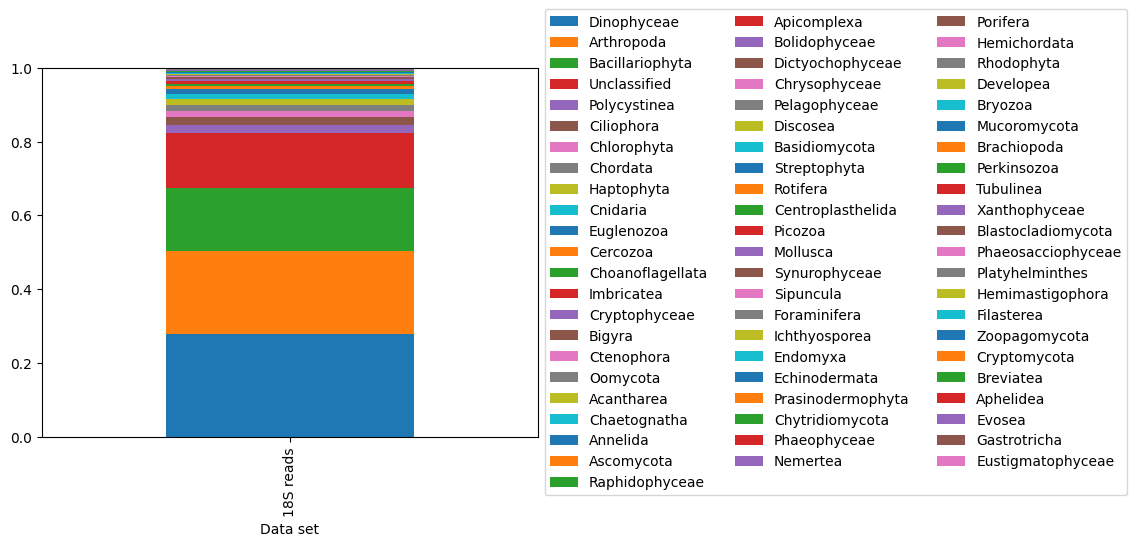

In [113]:
fig = plt.figure(figsize=(10,12))

pivot_18S_sort.plot(kind='bar', stacked=True)

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

plt.ylim(0, 1.0)

#plt.ylabel('Average % eukaryotic bps, reads, or ORFs', size=14)
#plt.xlabel('Sequence data set', size=16)
#plt.xticks(rotation=45, ha='right', size=14)

#plt.savefig('eCruises2018_2019_prok_vs_euk_reads.png', format='png', 
#            dpi=1200, bbox_inches='tight')
# show the graph
plt.show()

In [13]:
# COI genera
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/COI comparison")
tax_freq_COI = pd.read_csv("COI_frequencies_all_tax_ranks_withBacUnass.csv")
tax_freq_COI_euk = tax_freq_COI[tax_freq_COI['Domain'] == 'Eukaryota']
#genera_COI = list(tax_freq_COI['Genus'].unique())
#phyla_genera_COI = tax_freq_COI.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})

In [14]:
len(list(tax_freq_COI['COI sample'].unique()))

218

In [15]:
domain_COI = tax_freq_COI[['COI reads', 'Domain']].groupby('Domain').sum().reset_index()
domain_COI['fraction'] = domain_COI['COI reads'] / 218
domain_COI = domain_COI.drop('COI reads', axis=1)
domain_COI.head()

,Domain,fraction
0,Bacteria,0.000028
1,Eukaryota,0.660612
2,unassigned,0.337067


### Combine "unknown" and "unassigned" annotations with "Unclassified"

In [16]:
tax_freq_COI_euk.loc[tax_freq_COI_euk['Phylum'] == 'unknown', 'Phylum'] = "Unclassified"
tax_freq_COI_euk.loc[tax_freq_COI_euk['Phylum'] == 'unassigned', 'Phylum'] = "Unclassified"

In [17]:
tax_freq_COI_avg = tax_freq_COI_euk.groupby(['Phylum'], as_index=False)['COI reads'].agg('sum')
tax_freq_COI_avg['fraction'] = tax_freq_COI_avg['COI reads'] / 218
tax_freq_COI_avg['Data set'] = 'COI reads'
tax_freq_COI_avg_sort = tax_freq_COI_avg.sort_values(by='fraction', ascending=False).drop(columns='COI reads')
tax_freq_COI_avg_sort.head()

,Phylum,fraction,Data set
26,Haptophyta,0.201067,COI reads
4,Bacillariophyta,0.137842,COI reads
2,Arthropoda,0.118764,COI reads
49,Unclassified,0.058459,COI reads
38,Picozoa,0.030347,COI reads


In [18]:
tax_freq_COI_avg_sort['fraction'].sum()

np.float64(0.6606115515789978)

In [19]:
tax_freq_COI_avg_sort['Percent composition'] = tax_freq_COI_avg_sort['fraction'] / 0.66061155
euk_phyla_COI = tax_freq_COI_avg_sort.drop('fraction', axis=1).rename(columns = {'phylum' : 'Phylum'})
euk_phyla_COI = euk_phyla_COI.sort_values(by='Percent composition', ascending=False)
euk_phyla_COI['Data set'] = 'COI reads'
euk_phyla_COI.head()

,Phylum,Data set,Percent composition
26,Haptophyta,COI reads,0.304365
4,Bacillariophyta,COI reads,0.208658
2,Arthropoda,COI reads,0.179779
49,Unclassified,COI reads,0.088492
38,Picozoa,COI reads,0.045938


In [20]:
euk_phyla_COI['Percent composition'].sum()

np.float64(1.000000002390206)

In [119]:
pivot_COI = pd.pivot_table(data=euk_phyla_COI, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)
pivot_COI_sort = pivot_COI.sort_values(by='COI reads', axis=1, ascending=False)

In [120]:
pivot_COI_sort

Phylum,Haptophyta,Bacillariophyta,Arthropoda,Unclassified,Picozoa,Oomycota,Phaeophyceae,Cnidaria,Rotifera,Chlorophyta,...,Sipuncula,Hemichordata,Phoronida,Zoopagomycota,Ciliophora,Xenacoelomorpha,Ichthyosporea,Platyhelminthes,Onychophora,Glaucocystophyceae
Data set,,,,,,,,,,,,,,,,,,,,,
COI reads,0.304365,0.208658,0.179779,0.088492,0.045938,0.042401,0.028621,0.024176,0.012663,0.01245,...,0.000016,0.000006,0.000002,0.000001,9.260559e-07,8.953044e-07,8.828082e-07,6.879820e-07,5.147989e-07,2.349239e-07


<Figure size 1000x1200 with 0 Axes>

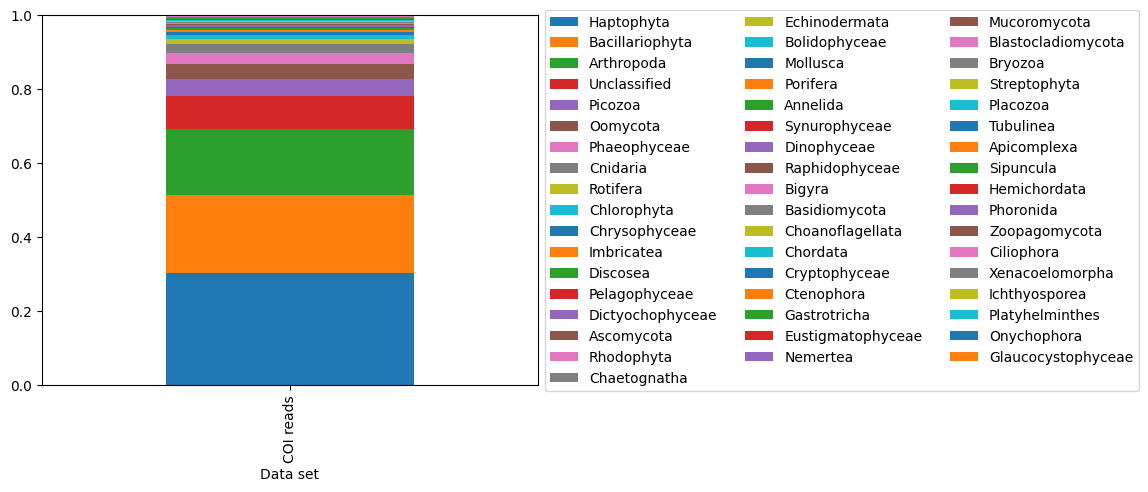

In [121]:
fig = plt.figure(figsize=(10,12))

pivot_COI_sort.plot(kind='bar', stacked=True)

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

plt.ylim(0, 1.0)

#plt.ylabel('Average % eukaryotic bps, reads, or ORFs', size=14)
#plt.xlabel('Sequence data set', size=16)
#plt.xticks(rotation=45, ha='right', size=14)

#plt.savefig('eCruises2018_2019_prok_vs_euk_reads.png', format='png', 
#            dpi=1200, bbox_inches='tight')
# show the graph
plt.show()

## 2. Calculate eukaryotic phylum composition in metagenome reads

In [21]:
# read fractions
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/sourmash")
reads = pd.read_csv("CCE_2018-2019.k51.tax.krona.tsv", sep='\t')
reads.head(3)

,fraction,superkingdom,phylum,class,order,family,genus,species
0,3.762682e-07,Eukaryota,Annelida,Clitellata,Crassiclitellata,Lumbricidae,Allolobophora,Allolobophora icterica
1,4.766149e-07,Eukaryota,Annelida,Clitellata,Crassiclitellata,Lumbricidae,Aporrectodea,Aporrectodea caliginosa
2,6.495863e-07,Eukaryota,Annelida,Clitellata,Rhynchobdellida,Glossiphoniidae,Placobdella,Placobdella costata


### Get domain fractions

In [22]:
reads_dom = reads[['fraction', 'superkingdom']].groupby('superkingdom').sum().reset_index()
reads_dom.head()

,superkingdom,fraction
0,Archaea,0.010992
1,Bacteria,0.119521
2,Eukaryota,0.010049
3,unclassified,0.867736


In [23]:
reads_euk = reads[reads['superkingdom'] == 'Eukaryota'][['fraction', 'phylum']].groupby('phylum').sum().reset_index()
reads_euk['fraction_euk'] = reads_euk['fraction'] / 0.010049
reads_euk.loc[reads_euk['phylum'] == 'unclassified Eukaryota phylum', 'phylum'] = "Unclassified"
reads_euk.head()

,phylum,fraction,fraction_euk
0,Annelida,0.000239,0.023793
1,Arthropoda,0.000234,0.023240
2,Ascomycota,0.000399,0.039701
3,Bacillariophyta,0.000388,0.038612
4,Basidiomycota,0.000016,0.001545


In [24]:
reads_euk['fraction_euk'].sum()

np.float64(0.9999530673282238)

In [25]:
reads_euk_phyla = reads_euk.rename(columns = {'phylum' : 'Phylum',
                                              'fraction_euk' : 'Percent composition'}).drop('fraction', axis=1)
reads_euk_phyla['Data set'] = 'Metagenome reads'
reads_euk_phyla.head()

,Phylum,Percent composition,Data set
0,Annelida,0.023793,Metagenome reads
1,Arthropoda,0.023240,Metagenome reads
2,Ascomycota,0.039701,Metagenome reads
3,Bacillariophyta,0.038612,Metagenome reads
4,Basidiomycota,0.001545,Metagenome reads


## 3. Metagenome contigs phyla

In [27]:
# contig TPMs
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/mmseqs")
contigs = pd.read_csv("contigs.mmseqs.tpms.krona.tsv", sep='\t')
contigs.loc[contigs['domain'] == 'Eukaryota incertae sedis', 'domain'] = "Unclassified"
contigs.head(3)

,fraction,domain,phylum,class,order,family,genus,species
0,4.619551e-06,Archaea,Candidatus Aenigmatarchaeota,Unclassified,Unclassified,Unclassified,Unclassified,Candidatus Aenigmarchaeota archaeon
1,4.532281e-09,Archaea,Candidatus Aenigmatarchaeota,Unclassified,Unclassified,Unclassified,Unclassified,Candidatus Aenigmarchaeota archaeon CG
2,1.207454e-08,Archaea,Candidatus Aenigmatarchaeota,Unclassified,Unclassified,Unclassified,Unclassified,Candidatus Aenigmarchaeota archaeon CG01


In [28]:
contigs['fraction'].sum()

np.float64(0.9999999999999828)

In [29]:
contigs_dom = contigs[['fraction', 'domain']]
contigs_dom = contigs_dom.groupby('domain').sum().reset_index()
contigs_dom

,domain,fraction
0,Archaea,0.073674
1,Bacteria,0.435892
2,Eukaryota,0.066087
3,Unclassified,0.424347


#### Generate phylum lists and average # genes across all metagenomes

In [33]:
contigs_euks = contigs[contigs['domain'] == 'Eukaryota'].drop(['class', 'order', 'family', 'genus', 'species'], axis=1)

# Sum across all samples first
mgns_euk_phyla = contigs_euks.drop(['domain'], axis=1).groupby('phylum').sum().reset_index()
mgns_euk_phyla.head()

,phylum,fraction
0,Acanthocephala,5.500235e-09
1,Annelida,2.532727e-05
2,Apicomplexa,4.077981e-05
3,Arthropoda,2.116943e-03
4,Ascomycota,4.738254e-04


In [34]:
mgns_euk_phyla['fraction'].sum()

np.float64(0.06608672287963699)

In [35]:
mgns_euk_phyla['fraction_euk'] = mgns_euk_phyla['fraction'] / 0.0660867
contigs_euk_phyla = mgns_euk_phyla.drop('fraction', axis=1).rename(columns = {'phylum' : 'Phylum',
                                                                             'fraction_euk' : 'Percent composition'})
contigs_euk_phyla = contigs_euk_phyla.sort_values(by='Percent composition', ascending=False)
contigs_euk_phyla['Data set'] = 'Metagenome contigs'
contigs_euk_phyla.head()

,Phylum,Percent composition,Data set
12,Chlorophyta,0.245719,Metagenome contigs
5,Bacillariophyta,0.189871,Metagenome contigs
59,Unclassified,0.139676,Metagenome contigs
28,Haptophyta,0.135004,Metagenome contigs
20,Dinophyceae,0.087459,Metagenome contigs


In [31]:
# number of unique genera in the metagenomes
genera_mgns = list(mgns['Genus'].unique())
len(genera_mgns)

6237

In [43]:
pivot = pd.pivot_table(data = contigs_euk_phyla, 
                       index = ['Data set'], 
                       columns = ['Phylum'], 
                       values = 'Percent composition').fillna(0)

In [44]:
pivot_sub = pivot[pivot > 0.001].dropna(axis='columns')
pivot_sub_sort = pivot_sub.sort_values(by='Metagenome contigs', axis=1, ascending=False)

In [45]:
pivot_sub_sort

Phylum,Chlorophyta,Bacillariophyta,Unclassified,Haptophyta,Dinophyceae,Pelagophyceae,Arthropoda,Chordata,Ciliophora,Streptophyta,...,Cnidaria,Mollusca,Basidiomycota,Nematoda,Euglenozoa,Mucoromycota,Prasinodermophyta,Rotifera,Cercozoa,Echinodermata
Data set,,,,,,,,,,,,,,,,,,,,,
Metagenome contigs,0.245719,0.189871,0.139676,0.135004,0.087459,0.073067,0.032033,0.021604,0.0169,0.016603,...,0.003422,0.003346,0.003329,0.002888,0.002157,0.001592,0.001568,0.001351,0.001329,0.001081


#### Get genus-level annotations

In [108]:
phyla_genera_class_mgns = mgns.groupby(['Phylum', 'Class', 'Order', 'Family', 'Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phyla_genera_mgns = mgns.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phyla_genera_mgns['Data set'] = 'Mgn'

In [109]:
phyla_genera_mgns.head()

,Phylum,Genus,number of occurrences,Data set
0,Acantharea,Astrolonche,25,Mgn
1,Acantharea,Phyllostaurus,5,Mgn
2,Acantharea,Stauracon,4,Mgn
3,Acanthocephala,Pomphorhynchus,2,Mgn
4,Actinophryidae,Actinophrys,6,Mgn


## 3. Compare domain-level composition

In [170]:
domain_COI.loc[domain_COI['Domain'] == 'unassigned', 'Domain'] = "Unclassified"
domain_COI['Data set'] = 'COI reads'
domain_COI

,Domain,fraction,Data set
0,Bacteria,0.000028,COI reads
1,Eukaryota,0.660612,COI reads
2,Unclassified,0.337067,COI reads


In [171]:
domain_18S.loc[domain_18S['Domain'] == 'unassigned', 'Domain'] = "Unclassified"
domain_18S['Data set'] = '18S reads'
domain_18S

,Domain,fraction,Data set
0,Eukaryota,0.885841,18S reads
1,Unclassified,0.114159,18S reads


In [175]:
reads_dom = reads_dom.rename(columns = {'superkingdom' : 'Domain'})
reads_dom.loc[reads_dom['Domain'] == 'unclassified', 'Domain'] = "Unclassified"
reads_dom['Data set'] = 'Metagenome reads'
reads_dom

,Domain,fraction,Data set
0,Archaea,0.010992,Metagenome reads
1,Bacteria,0.119521,Metagenome reads
2,Eukaryota,0.010049,Metagenome reads
3,Unclassified,0.867736,Metagenome reads


In [172]:
contigs_dom = contigs_dom.rename(columns = {'domain' : 'Domain'})
contigs_dom['Data set'] = 'Metagenome contigs'
contigs_dom

,Domain,fraction,Data set
0,Archaea,0.073674,Metagenome contigs
1,Bacteria,0.435892,Metagenome contigs
2,Eukaryota,0.066087,Metagenome contigs
3,Unclassified,0.424347,Metagenome contigs


In [176]:
dfs = [domain_18S, domain_COI, reads_dom, contigs_dom]
domain_df = pd.concat(dfs)
domain_df = domain_df.rename(columns = {'fraction' : 'Average % reads or contigs'})
domain_df

,Domain,Average % reads or contigs,Data set
0,Eukaryota,0.885841,18S reads
1,Unclassified,0.114159,18S reads
0,Bacteria,0.000028,COI reads
1,Eukaryota,0.660612,COI reads
2,Unclassified,0.337067,COI reads
0,Archaea,0.010992,Metagenome reads
1,Bacteria,0.119521,Metagenome reads
2,Eukaryota,0.010049,Metagenome reads
3,Unclassified,0.867736,Metagenome reads
0,Archaea,0.073674,Metagenome contigs


In [177]:
import seaborn.objects as so 
from seaborn import axes_style

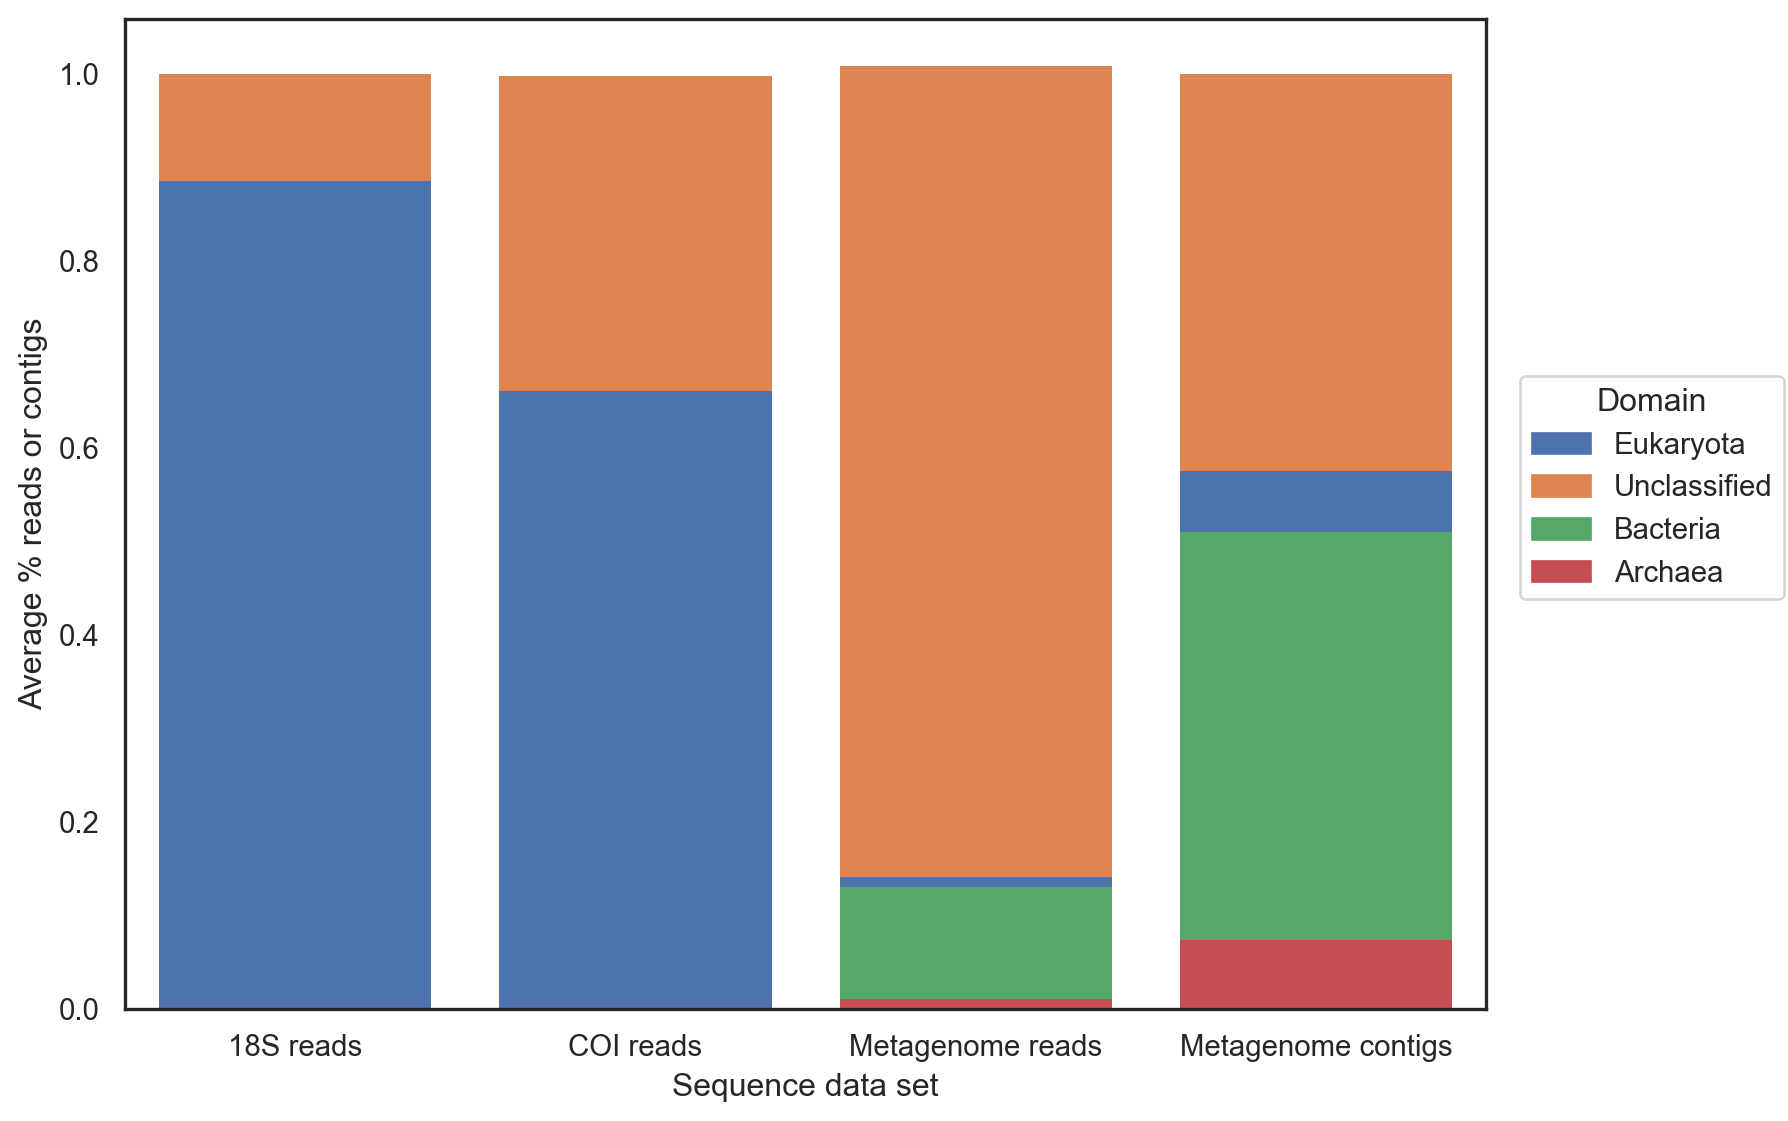

In [179]:
p = so.Plot(domain_df, 
            x="Data set", 
            y="Average % reads or contigs", 
            color="Domain").add(so.Bar(alpha=1.0), 
                                so.Stack()).layout(size=(8, 6))
p = p.theme(axes_style('white'))
p = p.label(x = 'Sequence data set')
p

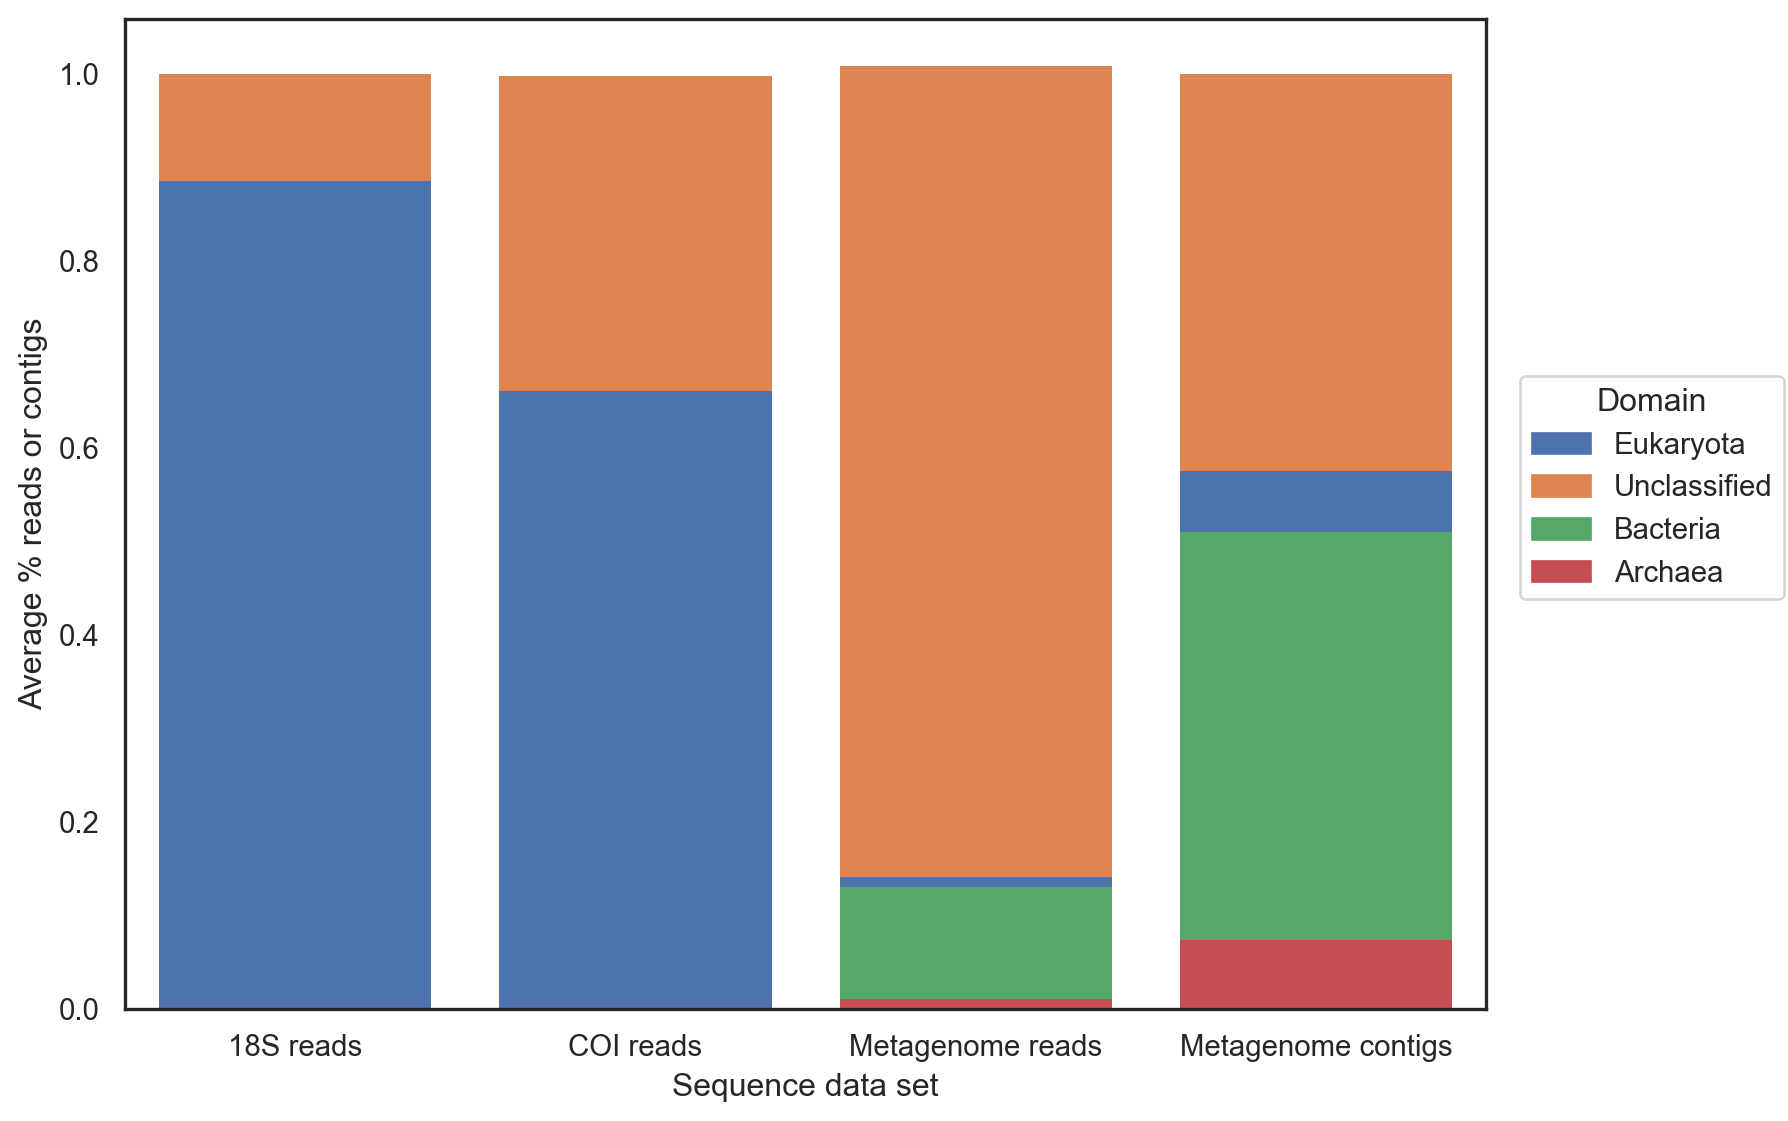

In [181]:
p.save('Domain_bars.svg', format='svg', 
            dpi=1200, bbox_inches='tight')

## 4. Compare phyla among data sets

In [36]:
dfs = [euk_phyla_18S, euk_phyla_COI, reads_euk_phyla, contigs_euk_phyla]
phyla_all = pd.concat(dfs)
phyla_all.head()

In [39]:
phyla_all[phyla_all['Phylum'] == 'Chlorophyta']

,Phylum,Data set,Percent composition
17,Chlorophyta,18S reads,0.017752
11,Chlorophyta,COI reads,0.012450
6,Chlorophyta,Metagenome reads,0.432605
12,Chlorophyta,Metagenome contigs,0.245719


In [40]:
pivot = pd.pivot_table(data=phyla_all, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)

In [41]:
pivot

Phylum,Acantharea,Acanthocephala,Annelida,Aphelidea,Apicomplexa,Arthropoda,Ascomycota,Bacillariophyta,Basidiomycota,Bigyra,...,Rotifera,Sipuncula,Streptophyta,Synurophyceae,Tardigrada,Tubulinea,Unclassified,Xanthophyceae,Xenacoelomorpha,Zoopagomycota
Data set,,,,,,,,,,,,,,,,,,,,,
18S reads,0.003088,0.000000e+00,0.001943,5.964760e-08,0.001475,0.225689,0.001850,0.169366,0.000604,0.004166,...,0.000339,0.000171,0.000414,0.000225,0.000000,0.000005,0.149293,0.000004,0.000000e+00,5.024268e-07
COI reads,0.000000,0.000000e+00,0.001726,0.000000e+00,0.000017,0.179779,0.003793,0.208658,0.000430,0.000632,...,0.012663,0.000016,0.000047,0.001568,0.000000,0.000017,0.088492,0.000000,8.953044e-07,1.496575e-06
Metagenome contigs,0.000000,8.322757e-08,0.000383,0.000000e+00,0.000617,0.032033,0.007170,0.189871,0.003329,0.000000,...,0.001351,0.000000,0.016603,0.000000,0.000148,0.000160,0.139676,0.000000,2.459421e-06,3.901536e-04
Metagenome reads,0.000000,0.000000e+00,0.023793,0.000000e+00,0.000000,0.023240,0.039701,0.038612,0.001545,0.000000,...,0.000000,0.000000,0.009080,0.000000,0.000000,0.000000,0.107923,0.000000,0.000000e+00,0.000000e+00


In [42]:
pivot.loc['max'] = pivot.max()
pivot

Phylum,Acantharea,Acanthocephala,Annelida,Aphelidea,Apicomplexa,Arthropoda,Ascomycota,Bacillariophyta,Basidiomycota,Bigyra,...,Rotifera,Sipuncula,Streptophyta,Synurophyceae,Tardigrada,Tubulinea,Unclassified,Xanthophyceae,Xenacoelomorpha,Zoopagomycota
Data set,,,,,,,,,,,,,,,,,,,,,
18S reads,0.003088,0.000000e+00,0.001943,5.964760e-08,0.001475,0.225689,0.001850,0.169366,0.000604,0.004166,...,0.000339,0.000171,0.000414,0.000225,0.000000,0.000005,0.149293,0.000004,0.000000e+00,5.024268e-07
COI reads,0.000000,0.000000e+00,0.001726,0.000000e+00,0.000017,0.179779,0.003793,0.208658,0.000430,0.000632,...,0.012663,0.000016,0.000047,0.001568,0.000000,0.000017,0.088492,0.000000,8.953044e-07,1.496575e-06
Metagenome contigs,0.000000,8.322757e-08,0.000383,0.000000e+00,0.000617,0.032033,0.007170,0.189871,0.003329,0.000000,...,0.001351,0.000000,0.016603,0.000000,0.000148,0.000160,0.139676,0.000000,2.459421e-06,3.901536e-04
Metagenome reads,0.000000,0.000000e+00,0.023793,0.000000e+00,0.000000,0.023240,0.039701,0.038612,0.001545,0.000000,...,0.000000,0.000000,0.009080,0.000000,0.000000,0.000000,0.107923,0.000000,0.000000e+00,0.000000e+00
max,0.003088,8.322757e-08,0.023793,5.964760e-08,0.001475,0.225689,0.039701,0.208658,0.003329,0.004166,...,0.012663,0.000171,0.016603,0.001568,0.000148,0.000160,0.149293,0.000004,2.459421e-06,3.901536e-04


### Filter out phyla that don't exceed 1% composition in any data set

In [43]:
mask = pivot.iloc[-1] > 0.01
pivot_sub = pivot.loc[:, mask]
pivot_sub_sort = pivot_sub.sort_values(by='max', axis=1, ascending=False)
pivot_sub_sort = pivot_sub_sort.iloc[:-1, :]
pivot_sub_sort

Phylum,Chlorophyta,Haptophyta,Dinophyceae,Arthropoda,Bacillariophyta,Unclassified,Pelagophyceae,Mollusca,Picozoa,Oomycota,...,Rhodophyta,Phaeophyceae,Cnidaria,Annelida,Chordata,Polycystinea,Ciliophora,Streptophyta,Rotifera,Euglenozoa
Data set,,,,,,,,,,,,,,,,,,,,,
18S reads,0.017752,0.015270,0.278676,0.225689,0.169366,0.149293,0.000783,0.000226,0.000317,0.003149,...,0.000023,0.000053,0.013873,0.001943,0.016384,0.021638,2.077675e-02,0.000414,0.000339,0.012323
COI reads,0.012450,0.304365,0.001272,0.179779,0.208658,0.088492,0.003981,0.001981,0.045938,0.042401,...,0.002995,0.028621,0.024176,0.001726,0.000334,0.000000,9.260559e-07,0.000047,0.012663,0.000000
Metagenome contigs,0.245719,0.135004,0.087459,0.032033,0.189871,0.139676,0.073067,0.003346,0.000077,0.005201,...,0.000659,0.000000,0.003422,0.000383,0.021604,0.000000,1.690018e-02,0.016603,0.001351,0.002157
Metagenome reads,0.432605,0.078607,0.075188,0.023240,0.038612,0.107923,0.042530,0.046783,0.000000,0.000000,...,0.032723,0.000000,0.012443,0.023793,0.023092,0.000000,3.090694e-05,0.009080,0.000000,0.000712


In [44]:
# Desired row order
new_order = ['18S reads', 'COI reads', 'Metagenome reads', 'Metagenome contigs']

# Reindex to change the row order
pivot_sub_sort = pivot_sub_sort.reindex(new_order)
pivot_sub_sort

Phylum,Chlorophyta,Haptophyta,Dinophyceae,Arthropoda,Bacillariophyta,Unclassified,Pelagophyceae,Mollusca,Picozoa,Oomycota,...,Rhodophyta,Phaeophyceae,Cnidaria,Annelida,Chordata,Polycystinea,Ciliophora,Streptophyta,Rotifera,Euglenozoa
Data set,,,,,,,,,,,,,,,,,,,,,
18S reads,0.017752,0.015270,0.278676,0.225689,0.169366,0.149293,0.000783,0.000226,0.000317,0.003149,...,0.000023,0.000053,0.013873,0.001943,0.016384,0.021638,2.077675e-02,0.000414,0.000339,0.012323
COI reads,0.012450,0.304365,0.001272,0.179779,0.208658,0.088492,0.003981,0.001981,0.045938,0.042401,...,0.002995,0.028621,0.024176,0.001726,0.000334,0.000000,9.260559e-07,0.000047,0.012663,0.000000
Metagenome reads,0.432605,0.078607,0.075188,0.023240,0.038612,0.107923,0.042530,0.046783,0.000000,0.000000,...,0.032723,0.000000,0.012443,0.023793,0.023092,0.000000,3.090694e-05,0.009080,0.000000,0.000712
Metagenome contigs,0.245719,0.135004,0.087459,0.032033,0.189871,0.139676,0.073067,0.003346,0.000077,0.005201,...,0.000659,0.000000,0.003422,0.000383,0.021604,0.000000,1.690018e-02,0.016603,0.001351,0.002157


In [45]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/Figures")

<Figure size 1000x1200 with 0 Axes>

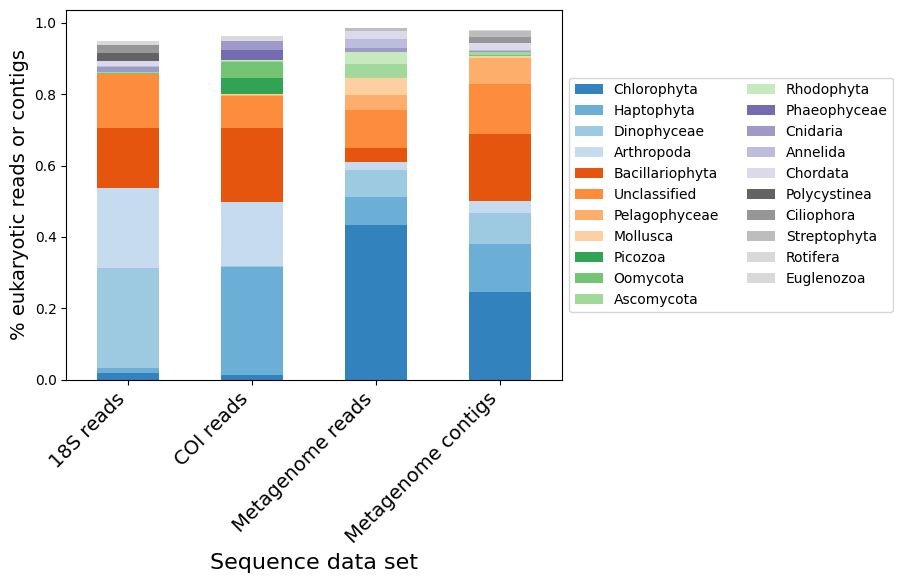

In [47]:
fig = plt.figure(figsize=(10,12))

# Set color map
cmap = plt.get_cmap('tab20c')

# Plot the bars
pivot_sub_sort.plot(kind='bar', stacked=True, cmap='tab20c')

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2)

plt.ylabel('% eukaryotic reads or contigs', size=14)
plt.xlabel('Sequence data set', size=16)
plt.xticks(rotation=45, ha='right', size=14)

# save the graph
plt.savefig('Phyla_bars.svg', format='svg', 
            dpi=1200, bbox_inches='tight')

# show the graph
plt.show()

## 4. Compare genera between ASV data sets

#### Taxa seen in either ASV data set, or in both

In [47]:
phyla_genera_COI.shape 

(264, 4)

In [117]:
phyla_genera_18S_COI = pd.merge(phyla_genera_18S, phyla_genera_COI, 
                                on=['Phylum', 'Genus'], how='outer', 
                                indicator=True).drop(columns={'number of occurrences_x', 'number of occurrences_y', 'Data set_x', 'Data set_y'})
phyla_genera_18S_COI.head()

,Phylum,Genus,_merge
0,Acantharea,Acanthocolla,left_only
1,Acantharea,Acanthometra,left_only
2,Acantharea,Acanthostaurus,left_only
3,Acantharea,Amphibelone,left_only
4,Acantharea,Gigartacon,left_only


In [118]:
# Separate out 18S-only and COI-only observed genera
phyla_genera_18S_only = phyla_genera_18S_COI[phyla_genera_18S_COI['_merge'] == 'left_only'].drop(columns={'_merge'})
phyla_genera_COI_only = phyla_genera_18S_COI[phyla_genera_18S_COI['_merge'] == 'right_only'].drop(columns={'_merge'})

In [120]:
# Make dfs for genera seen in both 18S and COI, or in either one
phyla_genera_18S_COI_both = phyla_genera_18S_COI[phyla_genera_18S_COI['_merge'] == 'both'].drop(columns={'_merge'})
phyla_genera_18S_COI_either = phyla_genera_18S_COI.drop(columns={'_merge'})

#### Taxa seen in either 18S or COI

In [121]:
phyla_genera_18S_COI_either

,Phylum,Genus
0,Acantharea,Acanthocolla
1,Acantharea,Acanthometra
2,Acantharea,Acanthostaurus
3,Acantharea,Amphibelone
4,Acantharea,Gigartacon
...,...,...
724,unknown,Sticholonche
725,unknown,Telonema
726,unknown,Telonemia
727,unknown,g_


#### Taxa seen across all data sets including metagenomes

In [123]:
phyla_genera_mgns = phyla_genera_mgns.drop(columns={'number of occurrences'})
df_all = phyla_genera_mgns.merge(phyla_genera_18S_COI_either.drop_duplicates(), on=['Phylum','Genus'], 
                   how='outer', indicator=True).drop(columns={'Data set'})

In [124]:
phyla_genera_mgns.head()

,Phylum,Genus,Data set
0,Acantharea,Astrolonche,Mgn
1,Acantharea,Phyllostaurus,Mgn
2,Acantharea,Stauracon,Mgn
3,Acanthocephala,Pomphorhynchus,Mgn
4,Actinophryidae,Actinophrys,Mgn


In [129]:
phyla_genera_mgns.shape

(6231, 3)

In [132]:
df_all.head()

,Phylum,Genus,_merge
0,Acantharea,Acanthocolla,right_only
1,Acantharea,Acanthometra,right_only
2,Acantharea,Acanthostaurus,right_only
3,Acantharea,Amphibelone,right_only
4,Acantharea,Astrolonche,left_only


#### Taxa seen only in metagenomes

In [126]:
df_mgns_only = df_all[df_all['_merge'] == 'left_only']
df_mgns_only = df_mgns_only.drop(columns={'_merge'})
df_mgns_only['Data set'] = 'Mgn'
df_mgns_only.head()

,Phylum,Genus,Data set
4,Acantharea,Astrolonche,Mgn
13,Acanthocephala,Pomphorhynchus,Mgn
14,Actinophryidae,Actinophrys,Mgn
15,Actinophryidae,Actinosphaerium,Mgn
16,Ancyromonadida,Ancyromonas,Mgn


In [127]:
df_mgns_only.shape

(5921, 3)

### Only in 18S, COI, or 18S and COI, but NOT in metagenomes

#### 18S only

In [68]:
# phyla_genera_18S_only already excludes genera seen in COI
df_18S = phyla_genera_mgns.merge(phyla_genera_18S_only.drop_duplicates(), on=['Phylum','Genus'], 
                   how='outer', indicator=True)
df_18S_only = df_18S[df_18S['_merge'] == 'right_only'].drop(columns={'_merge'})
df_18S_only['Data set'] = '18S'
df_18S_only.shape

(277, 5)

#### COI only

In [69]:
df_COI = phyla_genera_mgns.merge(phyla_genera_COI_only.drop_duplicates(), on=['Phylum','Genus'], 
                   how='outer', indicator=True)
df_COI_only = df_COI[df_COI['_merge'] == 'right_only'].drop(columns={'_merge'})
df_COI_only['Data set'] = 'COI'
df_COI_only.shape

(90, 5)

#### ASVs only

In [70]:
df_asvs_only = df_all[df_all['_merge'] == 'right_only'].drop(columns={'_merge'})
df_asvs_only['Data set'] = '18S or COI'
df_asvs_only

,Phylum,Genus,Data set
0,Acantharea,Acanthocolla,18S or COI
1,Acantharea,Acanthometra,18S or COI
2,Acantharea,Acanthostaurus,18S or COI
3,Acantharea,Amphibelone,18S or COI
5,Acantharea,Gigartacon,18S or COI
...,...,...,...
6645,unknown,Sticholonche,18S or COI
6646,unknown,Telonema,18S or COI
6647,unknown,Telonemia,18S or COI
6648,unknown,g_,18S or COI


### 4a. Format data for plotting

In [134]:
def compare_taxa_across_data_sets(dfs):
    phy_gen_mgns = pd.concat(dfs)
    phy_gen_mgns['genus count'] = 1
    phy_gen_mgns = phy_gen_mgns.drop(columns='Genus').groupby(['Phylum', 'Data set']).sum()
    pivot = pd.pivot_table(data=phy_gen_mgns, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='genus count').fillna(0)
    return(phy_gen_mgns, pivot)

#### To compare total numbers across all data sets

In [133]:
dfs = [phyla_genera_mgns, phyla_genera_18S, phyla_genera_COI]

#### To compare genera seen only in certain data sets

In [123]:
dfs = [df_mgns_only, df_18S_only, df_COI_only, df_asvs_only]

### 4b. Make the stacked bar plot

In [135]:
phy_gen_mgns, pivot = compare_taxa_across_data_sets(dfs)

In [125]:
# for the genera exclusive to each data set
pivot = pivot.reindex(['18S', 'COI', '18S or COI', 'Mgn'])

In [136]:
pivot.head()

Phylum,Acantharea,Acanthocephala,Actinophryidae,Ancyromonadida,Annelida,Aphelidea,Apicomplexa,Apusomonadida,Arthropoda,Ascomycota,...,Streptophyta,Synurophyceae,Tardigrada,Telonemida,Tsukubamonadida,Tubulinea,Xanthophyceae,Xenacoelomorpha,Zoopagomycota,unknown
Data set,,,,,,,,,,,,,,,,,,,,,
18S,12.0,0.0,0.0,0.0,39.0,1.0,3.0,0.0,26.0,14.0,...,10.0,3.0,0.0,0.0,0.0,4.0,1.0,0.0,1.0,9.0
COI,0.0,0.0,0.0,0.0,22.0,0.0,1.0,0.0,35.0,7.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
Mgn,3.0,1.0,2.0,3.0,85.0,1.0,29.0,3.0,1521.0,423.0,...,772.0,6.0,7.0,1.0,1.0,12.0,7.0,9.0,24.0,0.0


In [141]:
pivot_sorted = pivot.sort_values(by=pivot.index[2], ascending=False, axis=1) # index[3] 
pivot_sorted.head()

Phylum,Arthropoda,Chordata,Streptophyta,Ascomycota,Rhodophyta,Bacillariophyta,Basidiomycota,Chlorophyta,Mollusca,Cnidaria,...,Gastrotricha,Prasinodermophyta,Phoronida,Sticholonchida,Developea,Hemimastigophora,Imbricatea,Picozoa,Sipuncula,unknown
Data set,,,,,,,,,,,,,,,,,,,,,
18S,26.0,20.0,10.0,14.0,2.0,40.0,9.0,21.0,7.0,40.0,...,1.0,2.0,0.0,0.0,2.0,1.0,7.0,3.0,1.0,9.0
COI,35.0,19.0,1.0,7.0,7.0,18.0,1.0,7.0,9.0,32.0,...,2.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0
Mgn,1521.0,1084.0,772.0,423.0,215.0,209.0,208.0,202.0,202.0,131.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [142]:
# Remove genera with a sum across all data sets of <100 and combine into "Other" column
pivot_sorted.loc['sum'] = pivot_sorted.sum()
pivot_sorted['total'] = pivot_sorted.sum(axis=1)
pivot_sorted_sub = []
for column in pivot_sorted.columns:
    if pivot_sorted[column].sum() > 100:
        pivot_sorted_sub.append(column)
pivot_sorted_sub = pivot_sorted[pivot_sorted_sub].drop(columns={'total'})
pivot_sorted_sub['new total'] = pivot_sorted_sub.sum(axis=1)
pivot_sorted_sub = pd.concat([pivot_sorted_sub, pivot_sorted['total']], axis=1)
pivot_sorted_sub['Other'] = pivot_sorted_sub['total'] - pivot_sorted_sub['new total']
pivot_sorted_sub = pivot_sorted_sub.drop(columns = {'new total', 'total'})
pivot_sorted_sub = pivot_sorted_sub.drop(['sum'])
pivot_sorted_sub

,Arthropoda,Chordata,Streptophyta,Ascomycota,Rhodophyta,Bacillariophyta,Basidiomycota,Chlorophyta,Mollusca,Cnidaria,Ciliophora,Annelida,Nematoda,Phaeophyceae,Dinophyceae,Porifera,Platyhelminthes,Mucoromycota,Euglenozoa,Other
Data set,,,,,,,,,,,,,,,,,,,,
18S,26.0,20.0,10.0,14.0,2.0,40.0,9.0,21.0,7.0,40.0,36.0,39.0,0.0,5.0,80.0,7.0,2.0,2.0,6.0,220.0
COI,35.0,19.0,1.0,7.0,7.0,18.0,1.0,7.0,9.0,32.0,1.0,22.0,0.0,4.0,10.0,6.0,1.0,1.0,0.0,83.0
Mgn,1521.0,1084.0,772.0,423.0,215.0,209.0,208.0,202.0,202.0,131.0,113.0,85.0,82.0,82.0,71.0,55.0,50.0,50.0,47.0,629.0


#### With an axis break

[Text(0, 0, '18S'), Text(1, 0, 'COI'), Text(2, 0, 'Metagenomes')]

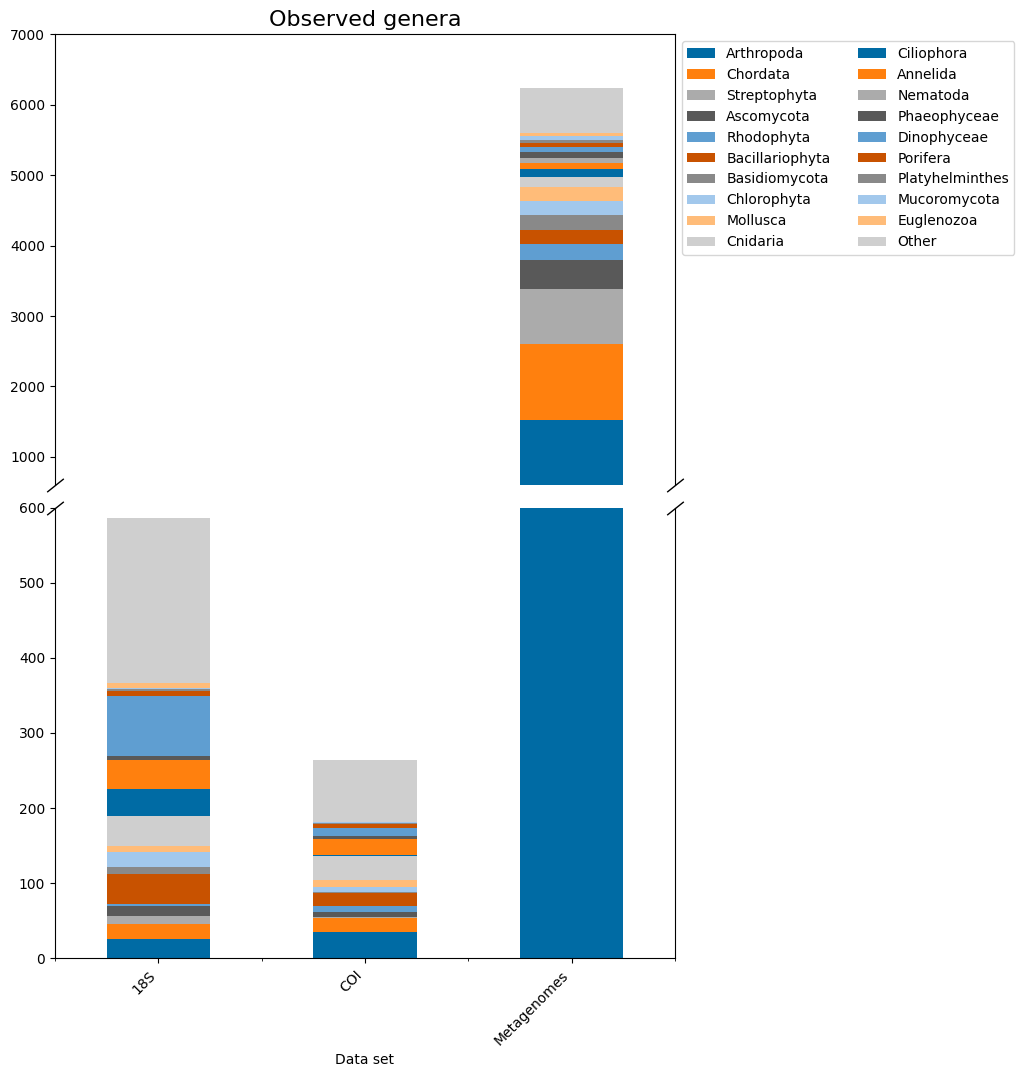

In [143]:
style.use('tableau-colorblind10')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8,12))
fig.subplots_adjust(hspace=0.05)  # adjust space between axes

# plot the same data on both axes
pivot_sorted_sub.plot(ax=ax1, kind='bar', stacked=True)
pivot_sorted_sub.plot(ax=ax2, kind='bar', stacked=True, legend=False)

# zoom-in / limit the view to different portions of the data
ax1.set_ylim(600, 7000)  # mgns
ax2.set_ylim(0, 600)  # asvs

# Hide the borders and generate break marks
ax1.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.tick_params(axis="x", which="both", length=0)
#ax1.tick_params(labelbottom="off")
ax2.tick_params(labeltop="off")
ax2.xaxis.tick_bottom()

d = 0.8  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# This labels the bottom (largest) section of the metagenome bar
#ax1.bar_label(ax1.containers[0], fmt=lambda x: x if x > 0 else '', label_type='edge')

ax1.legend(bbox_to_anchor=(1, 1),
          ncol=2, fancybox=True)
ax1.set_title('Observed genera', fontsize=16)
ax2.set_xticklabels(['18S', 'COI', 'Metagenomes'], ha='right', rotation=45)

In [144]:
fig.savefig('Genera_exlusive_to_each_dataset_sub100.png', bbox_inches='tight')